In [4]:
#Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno as msno
import warnings


from sklearn.preprocessing import LabelEncoder
from ipywidgets import interact, interactive, fixed, interact_manual
import gdown

warnings.filterwarnings('ignore')

In [5]:
import matplotlib.pyplot as plt

def plot_well_logs(df, well, lithology_col, colors,lithology,dz=100,figsize=(9,12)):
    fig, axes = plt.subplots(1, 5, figsize=figsize)

    # Definindo o limite vertical e adicionando grade
    for ax in axes:
        ax.set_ylim(df[df.WELL == well].DEPTH_MD.max() + dz, df[df.WELL == well].DEPTH_MD.min() - dz)
        ax.grid()

    # Primeiro gráfico: GR com CALI
    axes[0].plot(df[df.WELL == well].GR, df[df.WELL == well].DEPTH_MD, color='blue', lw=0.8, label='GR')
    ax0 = axes[0].twiny()
    ax0.plot(df[df.WELL == well].CALI, df[df.WELL == well].DEPTH_MD, c='r', ls='--', lw=0.8, label='CALI')
    ax0.legend(loc='upper left', fontsize=8)

    # Segundo gráfico: RDEP e RMED
    axes[1].plot(df[df.WELL == well].RDEP, df[df.WELL == well].DEPTH_MD, color='blue', lw=0.8, label='RILD')
    axes[1].plot(df[df.WELL == well].RMED, df[df.WELL == well].DEPTH_MD, color='red', lw=0.8, label='RILM', ls='--')
    axes[1].set_xscale('log')

    # Terceiro gráfico: DTC
    axes[2].plot(df[df.WELL == well].DTC, df[df.WELL == well].DEPTH_MD, color='blue', lw=0.8, label='DTC')

    # Quarto gráfico: RHOB com NPHI
    axes[3].plot(df[df.WELL == well].RHOB, df[df.WELL == well].DEPTH_MD, color='blue', lw=0.8, label='RHOB')
    ax3 = axes[3].twiny()
    ax3.plot(df[df.WELL == well].NPHI, df[df.WELL == well].DEPTH_MD, color='red', lw=0.8, label='NPHI', ls='--')


    for i,j in zip(lithology,colors):

        axes[4].fill_betweenx(df[df.WELL == well].DEPTH_MD, 0,
                           1, 
                           where=(df[df.WELL == well][lithology_col] == i), 
                           color=j, alpha=1,label=i)

    # Adicionando legendas em todos os gráficos
    for ax in axes:
        ax.legend(fontsize=8, loc='upper right')

    axes[4].legend(fontsize=5)

    # Ajustando o layout para evitar sobreposição
    fig.tight_layout()

    return fig, axes

In [6]:
colors = [
    "#fcf444",  # light yellow/pastel yellow
    "#C2B280",  # blue-green
    "#0AB63E",  # lime green / neon green
    "#3019a3",  # deep blue / electric blue
    "#046ccc",  # cyan blue
    "#c0fcfc",  # light cyan
    "#88fcfc",  # very light cyan / soft turquoise
    "#6cb4cc",  # light sky blue / light cerulean blue
    "#dc1cfc",  # bright magenta / electric purple
    "#1005bc",  # deep blue
    "#dedede",  # light gray
    "#fc0c34"   # gainsboro
]

lithology = [
    "Sandstone (Arenito)",
    "Sandstone/Shale (Arenito)",
    "Shale (Argilito)",
    "Marl (Marga)",
    "Dolomite (Dolomita)",
    "Limestone (Calcário)",  
    "Chalk (Giz)",
    "Halite (Halita)",
    "Anhydrite (Anidrita)",
    "Tuff (Tufo)",
    "Coal (Carvão)",
    "Basement (Substrato)" 
]

| Código  | Litologia                          
|---------|------------------------------------
| 30000   | Sandstone (Arenito)                
| 65030   | Sandstone/Shale (Arenito/Argilito) 
| 65000   | Shale (Argilito)                       
| 80000   | Marl (Marga)                       
| 74000   | Dolomite (Dolomita)                
| 70000   | Limestone (Calcário)               
| 70032   | Chalk (Giz)                        
| 88000   | Halite (Halita)                    
| 86000   | Anhydrite (Anidrita)               
| 99000   | Tuff (Tufo)                        
| 90000   | Coal (Carvão)                      
| 93000   | Basement (Substrato)               


In [7]:
# URL de download do drive
url = 'https://drive.google.com/uc?export=download&id=1u6_1ZMPIDy-agKZnKVUCp0t0bvK8ccPC'

In [8]:
#Fazendo o download do arquivo para pasta do drive
gdown.download(url, 'Dados/train.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1u6_1ZMPIDy-agKZnKVUCp0t0bvK8ccPC
To: c:\Users\Acer3\Github\Curso_UnB_IA\Dados\train.csv
100%|██████████| 89.6M/89.6M [00:22<00:00, 3.90MB/s]


'Dados/train.csv'

In [9]:
df = pd.read_csv('Dados/train.csv')

df.info() #informações sobre o dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746575 entries, 0 to 746574
Data columns (total 11 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   WELL                              746575 non-null  object 
 1   DEPTH_MD                          746575 non-null  float64
 2   CALI                              708506 non-null  float64
 3   RMED                              724221 non-null  float64
 4   RDEP                              738413 non-null  float64
 5   RHOB                              622971 non-null  float64
 6   GR                                746575 non-null  float64
 7   NPHI                              425137 non-null  float64
 8   DTC                               692120 non-null  float64
 9   FORCE_2020_LITHOFACIES_LITHOLOGY  746575 non-null  int64  
 10  GROUP                             746497 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 62.

In [10]:
#Todos os poços tem medidas nulas
df.dropna().info() 

<class 'pandas.core.frame.DataFrame'>
Index: 384968 entries, 4238 to 746574
Data columns (total 11 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   WELL                              384968 non-null  object 
 1   DEPTH_MD                          384968 non-null  float64
 2   CALI                              384968 non-null  float64
 3   RMED                              384968 non-null  float64
 4   RDEP                              384968 non-null  float64
 5   RHOB                              384968 non-null  float64
 6   GR                                384968 non-null  float64
 7   NPHI                              384968 non-null  float64
 8   DTC                               384968 non-null  float64
 9   FORCE_2020_LITHOFACIES_LITHOLOGY  384968 non-null  int64  
 10  GROUP                             384968 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 35.2+

In [11]:
#Verificando número de poços
print(f"Número de poços disponíveis: {len(df.WELL.unique())}")

Número de poços disponíveis: 40


In [12]:
#Criando novas variáveis a partir das variáveis categoricas
LabelEncoder_form = LabelEncoder()
LabelEncoder_group = LabelEncoder()

LabelEncoder_form.fit(df['GROUP'])

df['GROUP_num'] = LabelEncoder_form.transform(df['GROUP'])

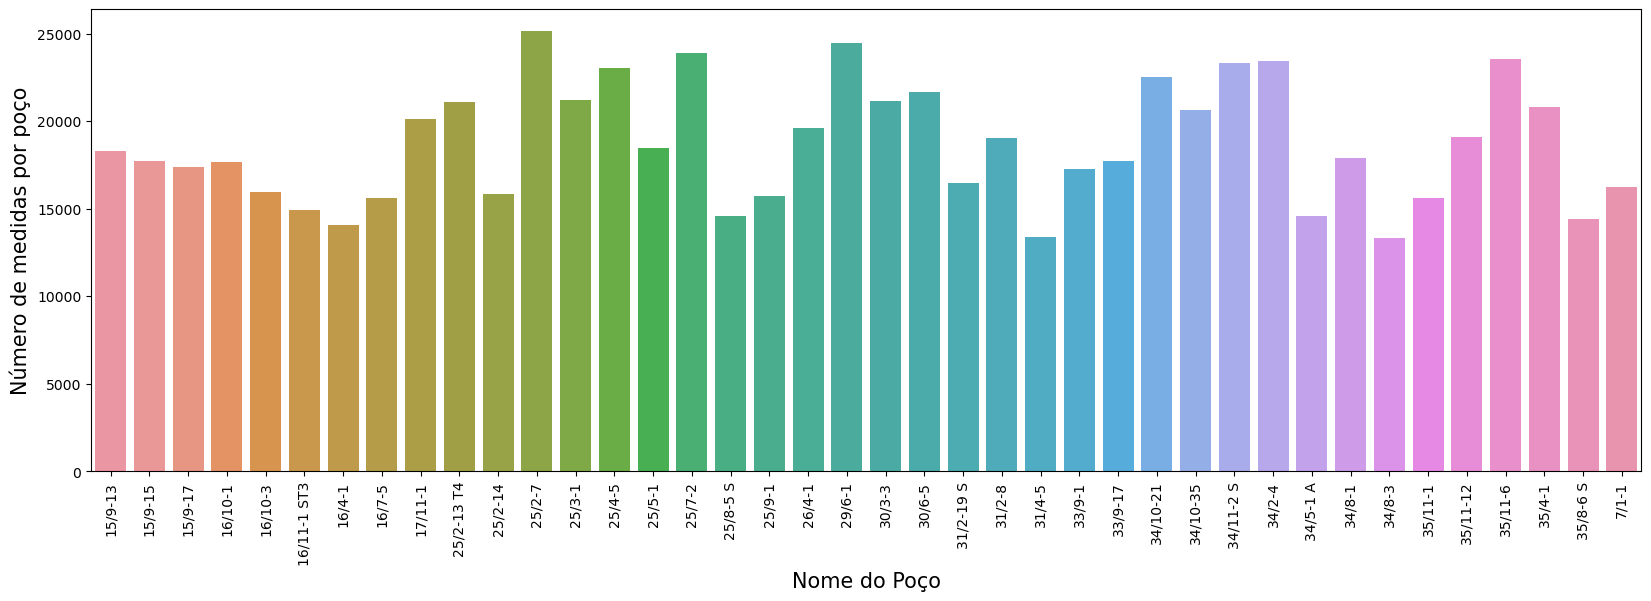

In [13]:
#Plotando um countplot para verificar o número de medidas de cada poço na vertical

fig,axes=plt.subplots(figsize=(20,6))
sns.countplot(x='WELL',data=df,ax=axes)
axes.set_xticklabels(axes.get_xticklabels(), rotation=90)
axes.set_xlabel('Nome do Poço',fontsize=15)
axes.set_ylabel('Número de medidas por poço',fontsize=15)
fig.show()

<Axes: >

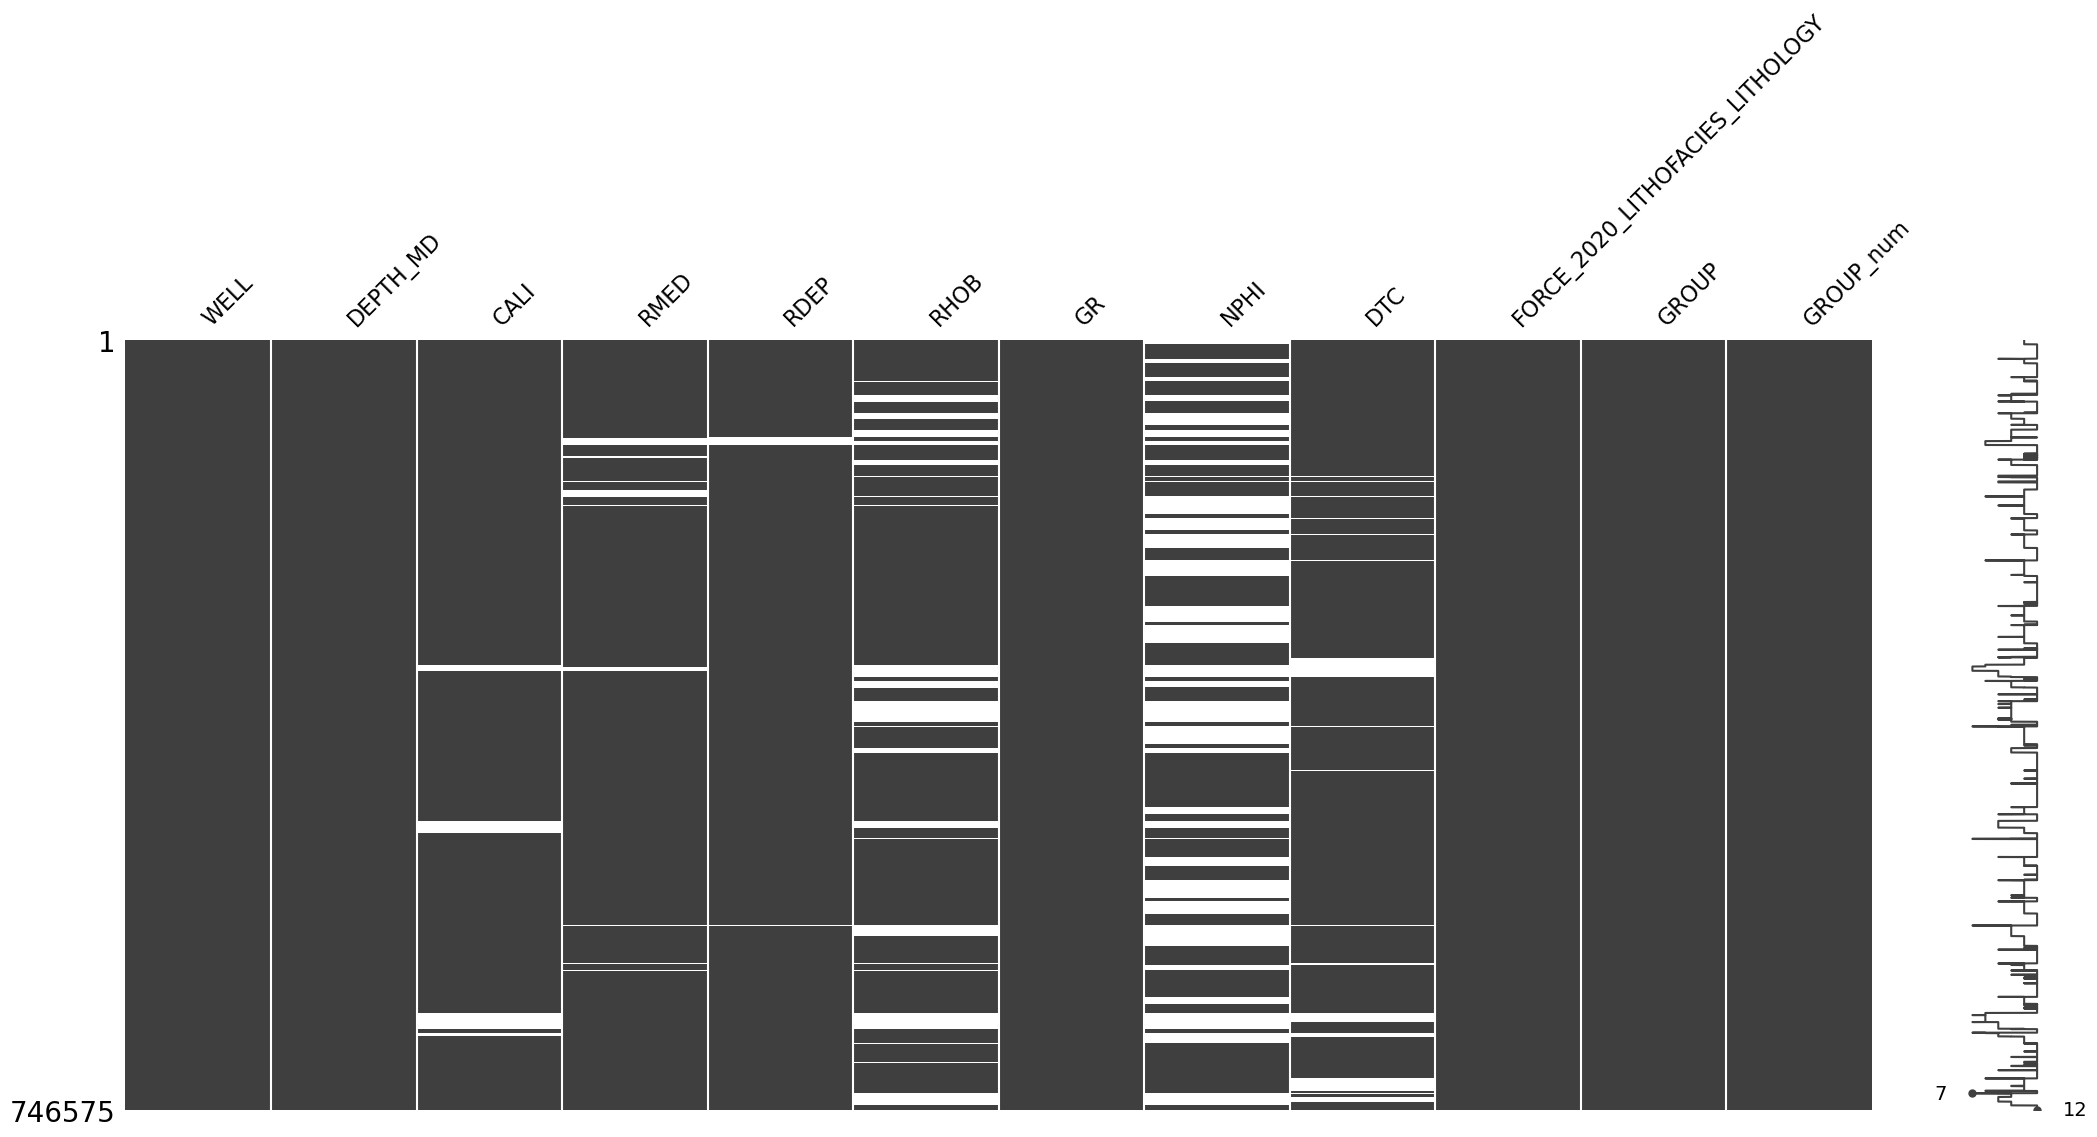

In [14]:
msno.matrix(df)

In [15]:
# dropando valores nulos
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384968 entries, 4238 to 746574
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   WELL                              384968 non-null  object 
 1   DEPTH_MD                          384968 non-null  float64
 2   CALI                              384968 non-null  float64
 3   RMED                              384968 non-null  float64
 4   RDEP                              384968 non-null  float64
 5   RHOB                              384968 non-null  float64
 6   GR                                384968 non-null  float64
 7   NPHI                              384968 non-null  float64
 8   DTC                               384968 non-null  float64
 9   FORCE_2020_LITHOFACIES_LITHOLOGY  384968 non-null  int64  
 10  GROUP                             384968 non-null  object 
 11  GROUP_num                         384968 non-null  int

In [16]:
#Criação de uma coluna com o nome das litologias
lithology_map = {
    30000: 'Sandstone (Arenito)',
    65030: 'Sandstone/Shale (Arenito/Argilito)',
    65000: 'Shale (Argilito)',
    80000: 'Marl (Marga)',
    74000: 'Dolomite (Dolomita)',
    70000: 'Limestone (Calcário)',
    70032: 'Chalk (Giz)',
    88000: 'Halite (Halita)',
    86000: 'Anhydrite (Anidrita)',
    99000: 'Tuff (Tufo)',
    90000: 'Coal (Carvão)',
    93000: 'Basement (Substrato)'
}
df['LITHOLOGY'] = df['FORCE_2020_LITHOFACIES_LITHOLOGY'].apply(lambda x: lithology_map.get(x, 'Unknown'))
df.head()

,WELL,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP,GROUP_num,LITHOLOGY
4238,15/9-13,1138.704,19.322735,1.013309,1.091499,1.774626,55.892757,0.765867,147.837677,30000,NORDLAND GP.,6,Sandstone (Arenito)
4239,15/9-13,1138.856,18.613674,1.088184,1.122706,1.800986,60.929138,0.800262,142.382431,65000,NORDLAND GP.,6,Shale (Argilito)
4240,15/9-13,1139.008,18.212072,1.127155,1.148141,1.817696,62.117264,0.765957,138.258331,65000,NORDLAND GP.,6,Shale (Argilito)
4241,15/9-13,1139.160,18.134182,1.141467,1.170984,1.829333,61.010860,0.702521,139.198914,65000,NORDLAND GP.,6,Shale (Argilito)
4242,15/9-13,1139.312,18.033762,1.138007,1.184080,1.813854,58.501236,0.639708,144.290085,65000,NORDLAND GP.,6,Shale (Argilito)


In [17]:
@interact(well=df.WELL.unique())
def update_well_plot(well):
    plot_well_logs(df, well=well,lithology_col='LITHOLOGY',colors=colors,lithology=lithology,dz=100)

interactive(children=(Dropdown(description='well', options=('15/9-13', '15/9-15', '15/9-17', '16/10-1', '16/10…

In [18]:
#Selecionando aleatóriamente 5 poços para serem selecionados como blind e o restante para realizar a aplicação

well_names = df.WELL.isin(np.random.choice(df.WELL.unique(),size=1))

blind = df[well_names]
dataset = df[~well_names]

print(f'Número de amostras separadas para o treino: {len(dataset)}\nNúmero de amostras separadas para o teste cego: {len(blind)}')
print(f'Propoção Teste cego / Treino: {len(blind)/len(dataset)*100:.2f}%')

Número de amostras separadas para o treino: 373365
Número de amostras separadas para o teste cego: 11603
Propoção Teste cego / Treino: 3.11%


In [19]:
dataset.describe()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num
count,373365.000000,373365.000000,373365.000000,373365.000000,373365.000000,373365.000000,373365.000000,373365.000000,373365.000000,373365.000000
mean,2583.750202,12.176407,4.677835,4.454637,2.331641,72.434211,0.342948,105.407019,61074.160717,6.392308
std,896.303206,3.245383,29.569688,35.822266,0.239375,34.431652,0.133046,28.125200,13583.602179,3.156570
min,414.761016,3.336693,0.095034,0.087607,1.058234,0.898921,-0.035822,7.415132,30000.000000,0.000000
25%,1947.656199,9.072617,1.018379,1.037553,2.162477,50.684586,0.254450,83.233940,65000.000000,3.000000
50%,2563.159790,12.289819,1.786511,1.653255,2.384004,71.911079,0.341419,98.718338,65000.000000,6.000000
75%,3194.576000,13.632648,3.927382,3.397065,2.516756,87.826378,0.432659,127.071747,65000.000000,9.000000
max,4927.276000,25.717396,1988.616333,1999.877808,3.262041,1076.963867,0.999570,320.478882,99000.000000,12.000000


In [20]:
blind.describe()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num
count,11603.000000,11603.000000,11603.000000,11603.000000,11603.000000,11603.000000,11603.000000,11603.000000,11603.000000,11603.000000
mean,3840.749094,11.275884,7.362382,8.410757,2.577708,89.285056,0.219592,82.478858,64003.719728,6.158407
std,520.435983,2.180713,8.998910,11.247829,0.087158,19.380939,0.090250,8.316517,10261.240801,4.075025
min,2947.216000,8.306801,1.454951,1.624593,1.780361,24.650202,0.014352,53.844212,30000.000000,0.000000
25%,3388.092000,9.320201,2.953381,3.015376,2.522313,80.898006,0.146777,76.078846,65000.000000,3.000000
50%,3830.032000,10.357321,5.357203,5.925819,2.589775,90.769264,0.216599,82.718582,65000.000000,9.000000
75%,4296.444000,12.875503,8.715951,9.236204,2.643631,102.186939,0.275574,89.067894,65030.000000,9.000000
max,4738.992000,19.182785,251.034882,292.351471,2.867275,173.760376,0.742356,117.912498,90000.000000,11.000000


(0.0, 5000.0)

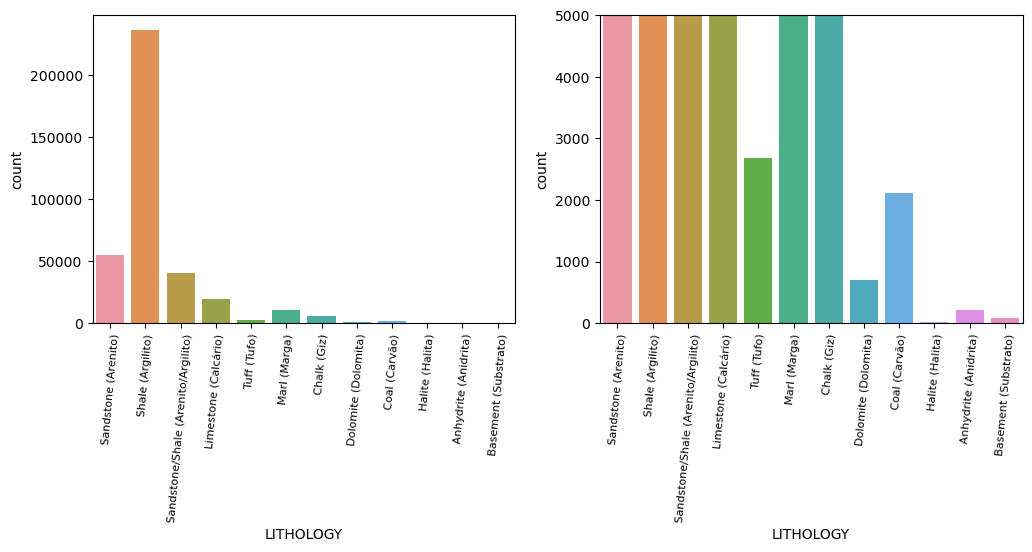

In [21]:
#Verificando a distribuição das classes
fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.countplot(x='LITHOLOGY', data=dataset,ax=axes[0])

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=85,fontsize=8)

sns.countplot(x='LITHOLOGY', data=dataset,ax=axes[1])

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=85,fontsize=8)
axes[1].set_ylim(0,5000)

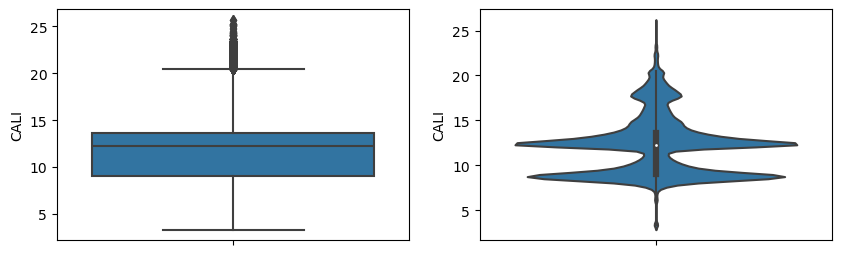

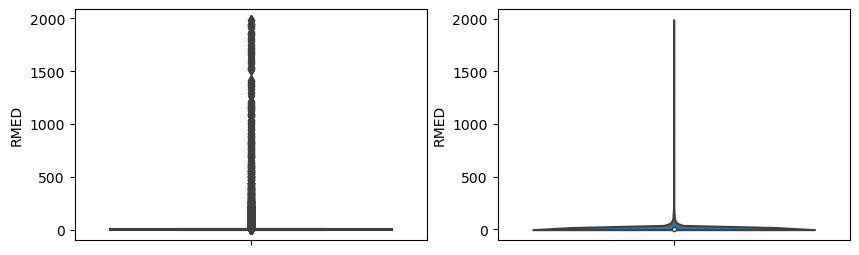

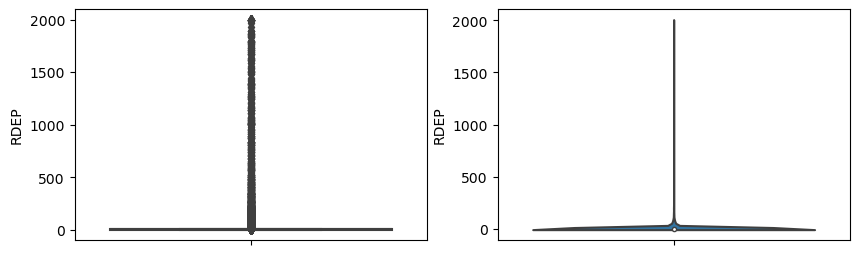

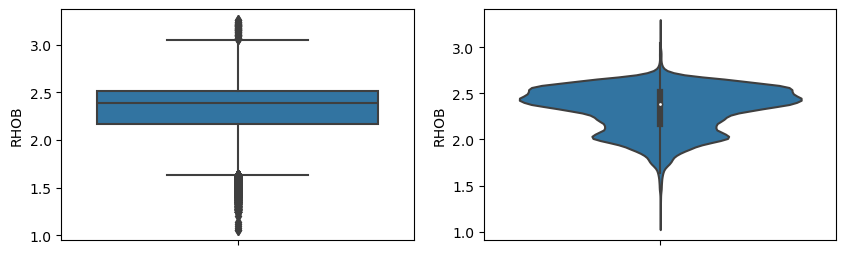

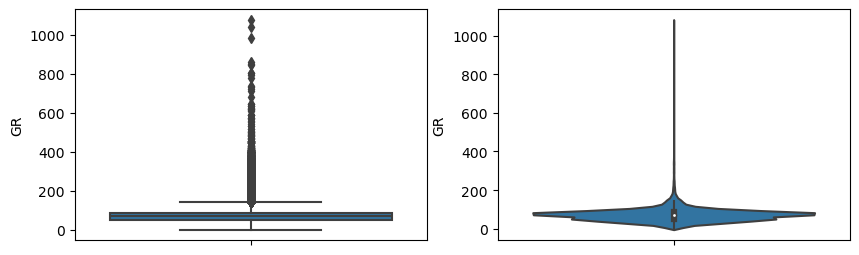

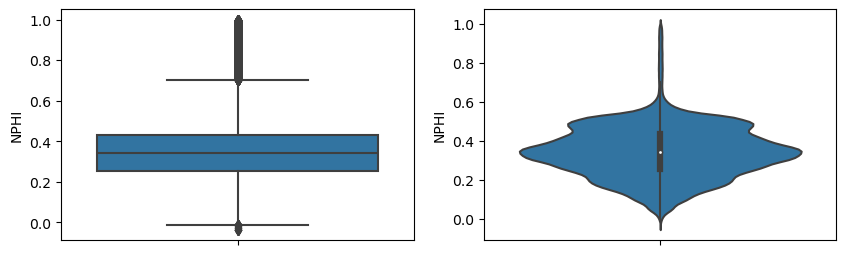

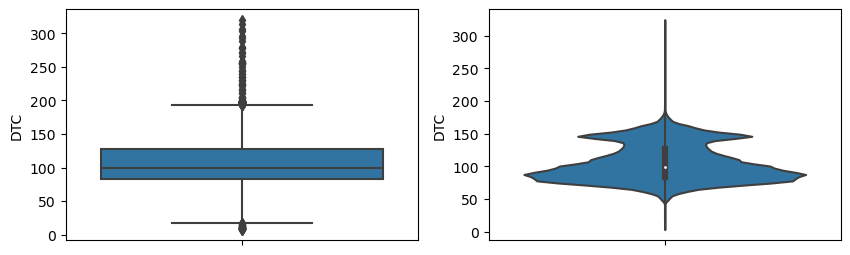

In [22]:
#Visualizando o boxplot das propriedades petrofísicas
cols = ['CALI', 'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'DTC']
for i in cols:
    fig,axes = plt.subplots(ncols=2,figsize=(10,3))
    sns.boxplot(y=i,data=dataset,ax=axes[0])
    sns.violinplot(y=i,data=dataset,ax=axes[1])
    fig.show()

In [23]:
#Aplicando o log em nos perfis de resistividade
dataset['RMED_log'] = np.log10(dataset['RMED'])
dataset['RDEP_log'] = np.log10(dataset['RDEP'])

#Aplicando o log em nos perfis de resistividade
blind['RMED_log'] = np.log10(blind['RMED'])
blind['RDEP_log'] = np.log10(blind['RDEP'])

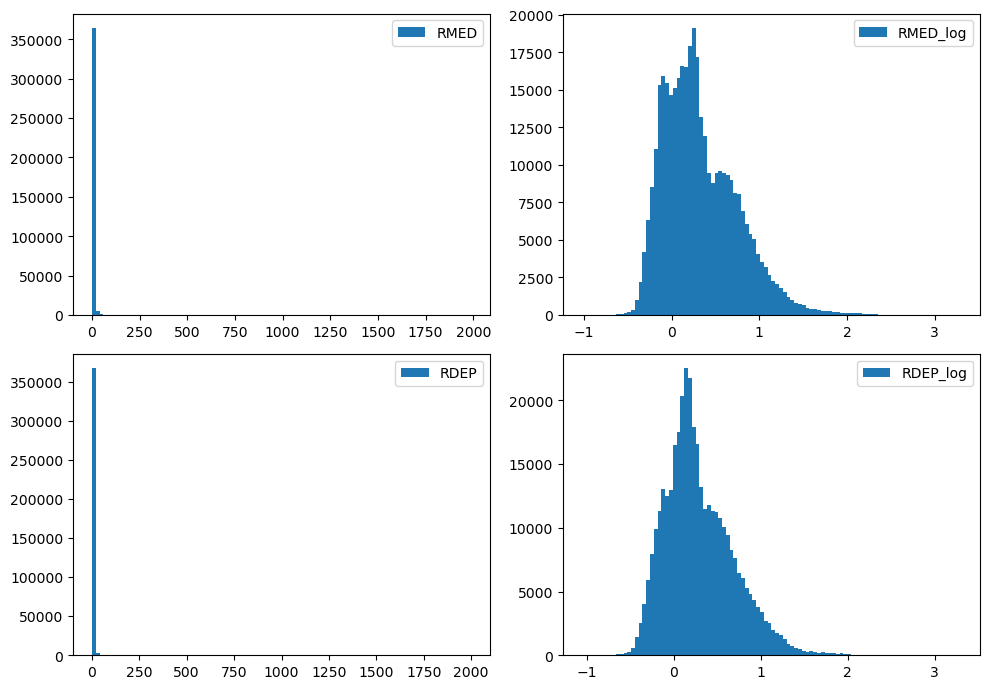

In [24]:
fig,axes = plt.subplots(2,2,figsize=(10,7))

axes[0][0].hist(dataset['RMED'],bins=100,label='RMED')
axes[0][1].hist(dataset['RMED_log'],bins=100,label='RMED_log')

axes[1][0].hist(dataset['RDEP'],bins=100,label='RDEP')
axes[1][1].hist(dataset['RDEP_log'],bins=100,label='RDEP_log')

for ax in axes:
    for ax1 in ax:
        ax1.legend()

fig.tight_layout()

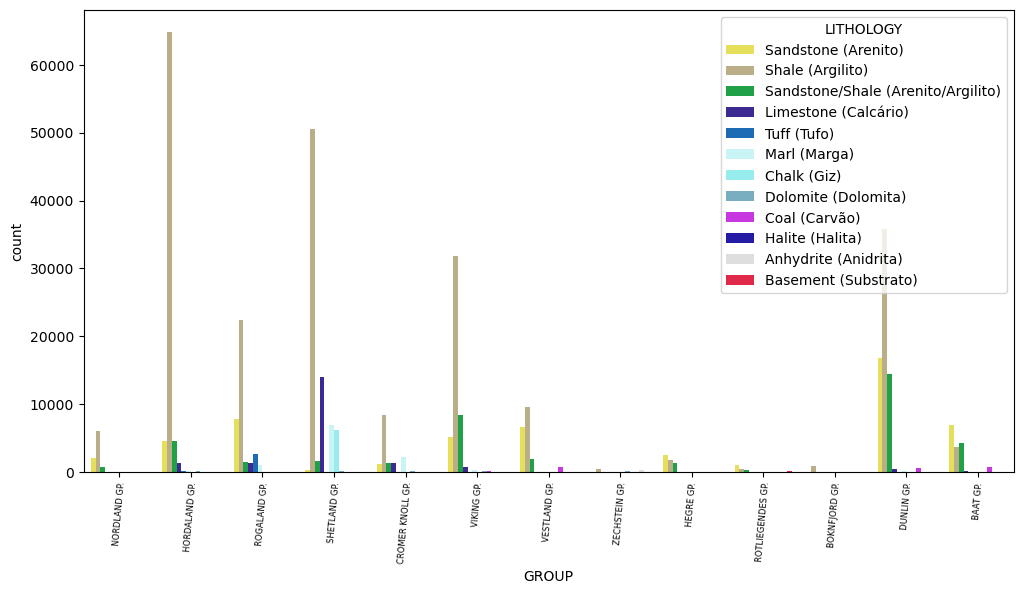

In [25]:
#Countplot das Formações com um hue=LITHOLOGY
fig,axes = plt.subplots(figsize=(12,6))

sns.countplot(x='GROUP', data=dataset,ax=axes,hue='LITHOLOGY',palette=colors)
axes.set_xticklabels(axes.get_xticklabels(), rotation=85,fontsize=6)

fig.show()

In [34]:
columns = dataset.select_dtypes(include=np.number).columns.tolist() + ['LITHOLOGY']
columns


['DEPTH_MD',
 'CALI',
 'RMED',
 'RDEP',
 'RHOB',
 'GR',
 'NPHI',
 'DTC',
 'FORCE_2020_LITHOFACIES_LITHOLOGY',
 'GROUP_num',
 'RMED_log',
 'RDEP_log',
 'LITHOLOGY']

In [37]:
dataset[columns].groupby('LITHOLOGY').min()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num,RMED_log,RDEP_log
LITHOLOGY,,,,,,,,,,,,
Anhydrite (Anidrita),2430.001604,12.611991,2.361164,3.467607,2.659892,9.195698,-0.013786,39.041588,86000,12,0.373126,0.540030
Basement (Substrato),2885.697604,12.338740,4.132351,7.812500,2.727421,22.531631,0.099438,43.564400,93000,8,0.616197,0.892790
Chalk (Giz),1160.169016,7.756689,0.095034,0.309384,2.110801,4.562729,0.020792,54.266239,70032,2,-1.022121,-0.509502
Coal (Carvão),2183.070000,6.942000,0.564622,0.438184,1.239131,7.043468,0.024577,59.118092,90000,0,-0.248242,-0.358343
Dolomite (Dolomita),779.132979,7.929700,0.476814,0.523961,1.830942,7.639176,0.005438,41.025799,74000,0,-0.321651,-0.280701
Halite (Halita),3115.831790,8.671869,2.915897,2.618155,1.609768,15.799763,0.008412,51.280060,88000,10,0.464772,0.417995
Limestone (Calcário),528.028979,3.374000,0.282922,0.375359,1.486390,5.951932,0.006201,34.664886,70000,0,-0.548333,-0.425554
Marl (Marga),592.297016,7.325138,0.498286,0.461613,1.795688,8.058441,0.044295,53.238892,80000,0,-0.302521,-0.335722
Sandstone (Arenito),469.177016,6.763310,0.181414,0.087607,1.058234,0.898921,-0.035822,38.963421,30000,0,-0.741330,-1.057460


In [36]:
dataset[columns].groupby('LITHOLOGY').mean()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num,RMED_log,RDEP_log
LITHOLOGY,,,,,,,,,,,,
Anhydrite (Anidrita),2518.284618,13.061506,392.712709,356.327984,2.910941,20.083008,0.009224,52.556700,86000.0,12.000000,2.166954,2.173114
Basement (Substrato),2892.644004,12.559565,8.579432,41.194221,2.894176,43.786369,0.161701,47.830768,93000.0,8.000000,0.910129,1.413327
Chalk (Giz),2108.118274,13.151115,2.422188,2.460400,2.440380,18.985851,0.171650,75.882739,70032.0,8.997408,0.258745,0.268043
Coal (Carvão),3421.879495,10.594516,54.738913,38.421747,1.905553,64.612414,0.434369,102.131722,90000.0,4.881324,1.159184,0.987444
Dolomite (Dolomita),2274.133705,13.241231,13.042606,16.477343,2.440054,60.596707,0.301248,94.225513,74000.0,7.564286,0.463725,0.414205
Halite (Halita),3119.084590,11.134469,13.034341,13.457758,1.915609,49.807429,0.163256,60.819875,88000.0,11.800000,0.986368,1.004128
Limestone (Calcário),2554.273053,12.105390,6.322331,5.320789,2.484406,34.522185,0.194545,79.390629,70000.0,8.011232,0.545920,0.489497
Marl (Marga),2687.147061,12.926245,3.020484,2.895138,2.469882,50.062092,0.273125,91.037037,80000.0,7.270397,0.378764,0.343626
Sandstone (Arenito),2894.972079,10.850729,7.543271,8.516845,2.332184,48.837202,0.238143,91.118176,30000.0,5.214250,0.382385,0.351501


In [38]:
dataset[columns].groupby('LITHOLOGY').max()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num,RMED_log,RDEP_log
LITHOLOGY,,,,,,,,,,,,
Anhydrite (Anidrita),2602.977604,14.489843,1841.164062,1894.385132,3.001404,43.581703,0.149037,80.150520,86000,12,3.265092,3.277468
Basement (Substrato),2899.681604,13.062956,20.014177,752.144959,3.054074,105.076424,0.243862,60.615841,93000,8,1.301338,2.876302
Chalk (Giz),2681.871790,16.649570,20.911963,20.071527,2.796767,74.287605,0.501065,115.866859,70032,9,1.320395,1.302580
Coal (Carvão),4836.280000,23.654171,1981.727417,1999.633667,2.870261,272.521729,0.771913,153.290329,90000,11,3.297044,3.300950
Dolomite (Dolomita),3374.594400,22.265053,1531.574219,669.239319,2.971166,142.598099,0.646222,162.738098,74000,12,3.185138,2.825581
Halite (Halita),3123.279790,12.662254,45.182999,41.020119,2.283624,78.285156,0.362868,73.235100,88000,12,1.654975,1.612997
Limestone (Calcário),4413.060000,23.713579,1859.126221,1856.935059,3.046810,205.451355,0.817310,167.779526,70000,12,3.269309,3.268797
Marl (Marga),3880.206400,21.846077,115.806114,426.207184,3.093508,196.702942,0.560239,181.061249,80000,11,2.063731,2.629621
Sandstone (Arenito),4927.276000,23.703100,1988.616333,1795.834595,2.973978,230.925903,0.913161,191.810150,30000,12,3.298551,3.254266


In [39]:
dataset[columns].groupby('LITHOLOGY').std()

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP_num,RMED_log,RDEP_log
LITHOLOGY,,,,,,,,,,,,
Anhydrite (Anidrita),69.009947,0.442627,503.591886,499.045240,0.064306,7.434106,0.031135,5.799322,0.0,0.000000,0.693492,0.582131
Basement (Substrato),4.163281,0.172444,2.982413,96.990345,0.066907,21.690171,0.039732,2.789494,0.0,0.000000,0.141146,0.282153
Chalk (Giz),519.895678,2.065836,2.109781,2.088629,0.101679,10.689019,0.074801,8.665947,0.0,0.128528,0.324847,0.324104
Coal (Carvão),601.349022,2.716725,179.595578,172.252819,0.350526,34.508336,0.116697,19.939654,0.0,4.414713,0.598233,0.529336
Dolomite (Dolomita),612.300061,3.181071,79.163300,72.429487,0.228968,19.837166,0.127979,30.010513,0.0,3.609340,0.545535,0.576909
Halite (Halita),2.927270,0.919877,12.260363,10.672868,0.183328,18.571133,0.115147,6.467630,0.0,0.615587,0.319245,0.348338
Limestone (Calcário),505.814413,2.475587,28.411937,35.877768,0.163823,23.953198,0.117317,19.690477,0.0,2.249576,0.412521,0.368505
Marl (Marga),537.728130,2.392696,4.036075,7.688920,0.134425,20.609097,0.087642,16.353675,0.0,2.898304,0.244547,0.241696
Sandstone (Arenito),924.108377,3.375910,41.964657,60.185960,0.204527,18.568507,0.112172,23.685877,0.0,3.438553,0.546428,0.535921


In [ ]:
dataset.head()

,WELL,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP,GROUP_num,LITHOLOGY,RMED_log,RDEP_log
4238,15/9-13,1138.704,19.322735,1.013309,1.091499,1.774626,55.892757,0.765867,147.837677,30000,NORDLAND GP.,6,Sandstone (Arenito),0.005742,0.038023
4239,15/9-13,1138.856,18.613674,1.088184,1.122706,1.800986,60.929138,0.800262,142.382431,65000,NORDLAND GP.,6,Shale (Argilito),0.036703,0.050266
4240,15/9-13,1139.008,18.212072,1.127155,1.148141,1.817696,62.117264,0.765957,138.258331,65000,NORDLAND GP.,6,Shale (Argilito),0.051984,0.059995
4241,15/9-13,1139.160,18.134182,1.141467,1.170984,1.829333,61.010860,0.702521,139.198914,65000,NORDLAND GP.,6,Shale (Argilito),0.057463,0.068551
4242,15/9-13,1139.312,18.033762,1.138007,1.184080,1.813854,58.501236,0.639708,144.290085,65000,NORDLAND GP.,6,Shale (Argilito),0.056145,0.073381


In [25]:
#Salvando o dataset com novas variáveis
dataset.to_csv('Dados/train_dataset_proc.csv')
blind.to_csv('Dados/blind_dataset_proc.csv')